## VLM 모델 사용 방법

경량 VLM 모델 로딩

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from PIL import Image
import os

model_id = "vikhyatk/moondream2"  # https://huggingface.co/vikhyatk/moondream2
device = "cuda" if torch.cuda.is_available() else "cpu"

# trust_remote_code=True 필수 (커스텀 아키텍처 사용)
model = AutoModelForCausalLM.from_pretrained(
    model_id, 
    trust_remote_code=True, 
    torch_dtype=torch.float16 # 16비트로 로드해도 VRAM 약 3.5GB 사용
).to(device)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)


Skipping import of cpp extensions due to incompatible torch version 2.7.0+cu118 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0316 16:06:13.684000 31180 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
`torch_dtype` is deprecated! Use `dtype` instead!


로컬 입력 이미지 로드

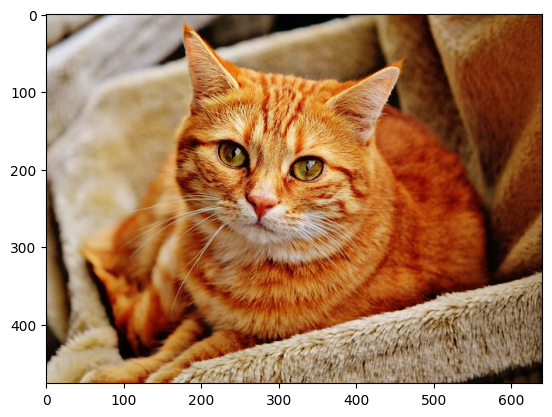

In [4]:
cur_module_path = './'
image_path = os.path.join(cur_module_path, "cat3.jpg")
image = Image.open(image_path).convert("RGB")

import matplotlib.pyplot as plt
plt.imshow(image)


모델 추론

In [5]:
print("모델 추론 중...")

# 이미지를 인코딩 (Vision Encoder)
enc_image = model.encode_image(image)

# 질문 생성 (Moondream은 영어 베이스)
prompt = "Describe this image in detail."
answer = model.answer_question(enc_image, prompt, tokenizer) # 텍스트와 이미지 결합 후 답변 생성

print("\n[답변]")
print(answer)

모델 추론 중...

[답변]
A ginger cat with vibrant green eyes is comfortably nestled in a cream-colored, fluffy bed. The cat's fur is a mix of orange and red, with a slightly lighter shade on its chest and underbelly. Its head is slightly tilted to the left, as it gazes directly into the camera. The cat's expression appears calm and relaxed. The blurred background draws focus to the cat and its cozy spot. The cat also has erect, pointed ears.
